# Задача 2: Анализ тональности с помощью keras — решение

**Цель**: построить и оценить нейросетевую модель для классификации текстов по тональности.

Этот ноутбук оформлен как **готовая сдача**: сначала выполнен базовый уровень (до 7 баллов), затем добавлены 3 расширения уровня 2 (до 10 баллов).

---

### Что сделано

| Шаг | Описание |
|-----|----------|
| 1 | Подготовка данных: тексты + метки |
| 2 | Векторизация TF-IDF + train/test split |
| 3 | Бинарная модель keras (Dense + ReLU + sigmoid) |
| 4 | Метрики F1 / Precision / Recall |
| 5 | Графики loss и accuracy |
| 6 | Дополнения уровня 2: Dropout+EarlyStopping, мультикласс, сравнение архитектур |

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score

from tensorflow import keras
from tensorflow.keras import layers

Примечание по окружению:
- Если возникает `ModuleNotFoundError: No module named tensorflow`, установите пакет в активный kernel.

Для обычного окружения:

```python
%pip install tensorflow
```

Для macOS с Homebrew Python (PEP 668) может потребоваться:

```python
%pip install tensorflow --break-system-packages
```

Для Apple Silicon при необходимости можно попробовать:

```python
%pip install tensorflow-macos --break-system-packages
```

## Шаг 1. Данные

40 отзывов: 15 позитивных, 15 негативных, 10 нейтральных.

Для базового примера используем **бинарную классификацию** (позитив / негатив).

In [8]:
sentiment_data = {
    "text": [
        # --- позитив (1) ---
        "Отличный фильм, очень понравился!",
        "Прекрасная книга, рекомендую всем прочитать.",
        "Качественный товар, доволен покупкой.",
        "Замечательный сервис, быстро и профессионально.",
        "Потрясающий ресторан, вкусная еда и уютная атмосфера.",
        "Великолепный спектакль, получил массу удовольствия.",
        "Отличное приложение, удобный интерфейс.",
        "Прекрасный отель, комфортные номера и хороший завтрак.",
        "Замечательный преподаватель, интересные лекции.",
        "Потрясающая музыка, слушаю постоянно.",
        "Отличный телефон, все работает быстро.",
        "Прекрасный подарок, очень доволен.",
        "Качественный кофе, ароматный и вкусный.",
        "Замечательный парк, красивая природа.",
        "Потрясающий концерт, незабываемые эмоции.",
        # --- негатив (0) ---
        "Ужасный фильм, полная потеря времени.",
        "Плохая книга, скучно и неинтересно.",
        "Низкое качество товара, очень разочарован.",
        "Плохой сервис, долго ждал и ничего не получил.",
        "Отвратительный ресторан, невкусная еда.",
        "Скучный спектакль, не рекомендую.",
        "Плохое приложение, постоянно глючит.",
        "Ужасный отель, грязные номера и плохое обслуживание.",
        "Скучный преподаватель, неинтересные лекции.",
        "Плохая музыка, не понравилась.",
        "Плохой телефон, постоянно зависает.",
        "Разочаровался в подарке, не то что ожидал.",
        "Плохой кофе, безвкусный и холодный.",
        "Запущенный парк, грязно и неухоженно.",
        "Скучный концерт, не оправдал ожиданий.",
        # --- нейтрал (2) ---
        "Обычный фильм, ничего особенного.",
        "Стандартная книга, читается нормально.",
        "Обычный товар, соответствует описанию.",
        "Нормальный сервис, без особых претензий.",
        "Обычный ресторан, стандартное меню.",
        "Средний спектакль, можно посмотреть.",
        "Обычное приложение, работает как надо.",
        "Стандартный отель, без изысков.",
        "Обычный преподаватель, стандартные лекции.",
        "Средняя музыка, ничего особенного.",
    ],
    "sentiment": [
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
    ]
}

df = pd.DataFrame(sentiment_data)

print(f"Всего отзывов: {len(df)}")
print(df["sentiment"].value_counts().sort_index().rename(
    {0: "негатив", 1: "позитив", 2: "нейтрал"}
))

Всего отзывов: 40
sentiment
негатив    15
позитив    15
нейтрал    10
Name: count, dtype: int64


## Шаг 2. Векторизация текстов (TF-IDF)

Нейросеть работает с числами, а не с текстом. **TF-IDF** превращает каждый текст в вектор чисел, где каждое число — «важность» конкретного слова.

```
"Отличный фильм"  →  [0.0, 0.71, 0.0, 0.71, ...]
```

In [ ]:
# Для бинарной классификации берём только позитив (1) и негатив (0)
df_binary = df[df["sentiment"] != 2].copy()

texts = df_binary["text"].values
y = df_binary["sentiment"].values

# Сначала делим тексты, потом обучаем TF-IDF только на train (без утечки данных)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts, y, test_size=0.3, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(X_train_text).toarray()
X_test = vectorizer.transform(X_test_text).toarray()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train.shape[0]} примеров, {X_train.shape[1]} признаков")
print(f"Тестовая выборка:  {X_test.shape[0]} примеров")

Обучающая выборка: 21 примеров, 100 признаков
Тестовая выборка:  9 примеров


## Шаг 3. Строим нейросеть на keras

Архитектура сети:

```
Вход (100 признаков)
    ↓
Dense(32, relu)    ← 32 нейрона, активация ReLU
    ↓
Dense(16, relu)    ← 16 нейронов
    ↓
Dense(1, sigmoid)  ← 1 выход: вероятность «позитив»
```

| Что | Зачем |
|-----|-------|
| `Dense` | Полносвязный слой — каждый нейрон связан с каждым входом |
| `relu` | Активация: пропускает положительные значения, обнуляет отрицательные |
| `sigmoid` | На выходе: превращает число в вероятность от 0 до 1 |
| `binary_crossentropy` | Функция ошибки для бинарной классификации |
| `adam` | Оптимизатор — автоматически подбирает скорость обучения |

In [17]:
# ---------- Создаём модель ----------
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])

# ---------- Компиляция ----------
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

# ---------- Обучение ----------
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=8,
    validation_split=0.2,
    verbose=0,
)

print("Модель обучена!")
model.summary()

Модель обучена!


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,333 (44.27 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,556 (29.52 KB)

## Шаг 4. Оцениваем качество

Смотрим три метрики:

| Метрика | Что показывает |
|---------|---------------|
| **F1-score** | Баланс между точностью и полнотой (основная метрика) |
| **Precision** | Из всех, кого модель назвала «позитив», сколько действительно позитивных |
| **Recall** | Из всех реально позитивных, сколько модель нашла |

In [21]:
# Получаем предсказания
y_pred = (model.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

# Считаем метрики
f1  = f1_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)

print(f"F1-score:  {f1:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")

F1-score:  0.0000
Precision: 0.0000
Recall:    0.0000


## Шаг 5. Графики обучения

По графикам видно, как модель училась:
- **Loss** (ошибка) должна уменьшаться
- **Accuracy** (точность) — расти
- Если `val_loss` растёт, а `loss` падает — модель **переобучается**

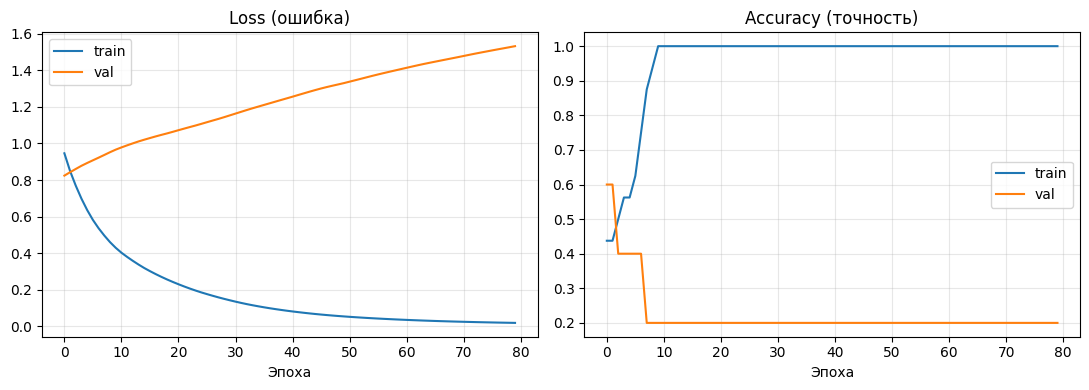

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss (ошибка)")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy (точность)")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---

## Промежуточный итог после базового уровня

На этом этапе уже выполнены требования на 7 баллов:

1. Подготовлены данные и сделан train/test split.
2. Построена и обучена бинарная модель keras.
3. Посчитаны F1-score, Precision и Recall.
4. Построены графики обучения.
5. Добавлены пояснения по слоям, loss, `fit()` и `predict()`.

Далее идут дополнительные пункты уровня 2 для повышения до 10 баллов.

## Уровень 2: Дополнительные пункты (до 10 баллов)

Ниже реализованы 3 дополнительных пункта:
1. Dropout + Early Stopping
2. Мультиклассовая классификация (3 класса)
3. Сравнение 3 архитектур по метрикам

In [18]:
# Пункт 1: Dropout + Early Stopping

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

model_dropout = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.35),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(1, activation="sigmoid"),
])

model_dropout.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0,
)

y_pred_dropout = (model_dropout.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

f1_d = f1_score(y_test, y_pred_dropout, zero_division=0)
pre_d = precision_score(y_test, y_pred_dropout, zero_division=0)
rec_d = recall_score(y_test, y_pred_dropout, zero_division=0)

print(f"Эпох обучено: {len(history_dropout.history['loss'])}")
print(f"F1-score (Dropout+ES):  {f1_d:.4f}")
print(f"Precision (Dropout+ES): {pre_d:.4f}")
print(f"Recall (Dropout+ES):    {rec_d:.4f}")

Эпох обучено: 86
F1-score (Dropout+ES):  0.2222
Precision (Dropout+ES): 0.2000
Recall (Dropout+ES):    0.2500


Почему это помогает:
- Dropout случайно выключает часть нейронов на обучении, поэтому сеть меньше переобучается.
- Early Stopping останавливает обучение, когда качество на валидации перестает улучшаться.

### Пункт 2: Мультиклассовая классификация (3 класса)

Используем все классы (негатив/позитив/нейтрал), выходной слой `Dense(3, softmax)` и функцию потерь `categorical_crossentropy`.

In [ ]:
from sklearn.metrics import classification_report

texts_multi = df["text"].values
y_multi = df["sentiment"].values

# Сначала split, затем fit TF-IDF только на train (без утечки данных)
X_train_text_m, X_test_text_m, y_train_m, y_test_m = train_test_split(
    texts_multi, y_multi, test_size=0.3, random_state=42, stratify=y_multi
)

vectorizer_multi = TfidfVectorizer(max_features=150, ngram_range=(1, 2))
X_train_m = vectorizer_multi.fit_transform(X_train_text_m).toarray()
X_test_m = vectorizer_multi.transform(X_test_text_m).toarray()

scaler_multi = StandardScaler()
X_train_m = scaler_multi.fit_transform(X_train_m)
X_test_m = scaler_multi.transform(X_test_m)

y_train_m_cat = keras.utils.to_categorical(y_train_m, num_classes=3)
y_test_m_cat = keras.utils.to_categorical(y_test_m, num_classes=3)

model_multi = keras.Sequential([
    layers.Input(shape=(X_train_m.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(3, activation="softmax"),
])

model_multi.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

early_stopping_multi = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
)

history_multi = model_multi.fit(
    X_train_m,
    y_train_m_cat,
    epochs=160,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stopping_multi],
    verbose=0,
)

y_pred_multi = np.argmax(model_multi.predict(X_test_m, verbose=0), axis=1)

f1_m = f1_score(y_test_m, y_pred_multi, average="macro", zero_division=0)
pre_m = precision_score(y_test_m, y_pred_multi, average="macro", zero_division=0)
rec_m = recall_score(y_test_m, y_pred_multi, average="macro", zero_division=0)

print(f"F1-macro:        {f1_m:.4f}")
print(f"Precision-macro: {pre_m:.4f}")
print(f"Recall-macro:    {rec_m:.4f}")
print()
print(classification_report(
    y_test_m,
    y_pred_multi,
    target_names=["негатив", "позитив", "нейтрал"],
    zero_division=0,
))

F1-macro:        0.3833
Precision-macro: 0.3111
Recall-macro:    0.5000

              precision    recall  f1-score   support

     негатив       0.00      0.00      0.00         5
     позитив       0.33      0.50      0.40         4
     нейтрал       0.60      1.00      0.75         3

    accuracy                           0.42        12
   macro avg       0.31      0.50      0.38        12
weighted avg       0.26      0.42      0.32        12



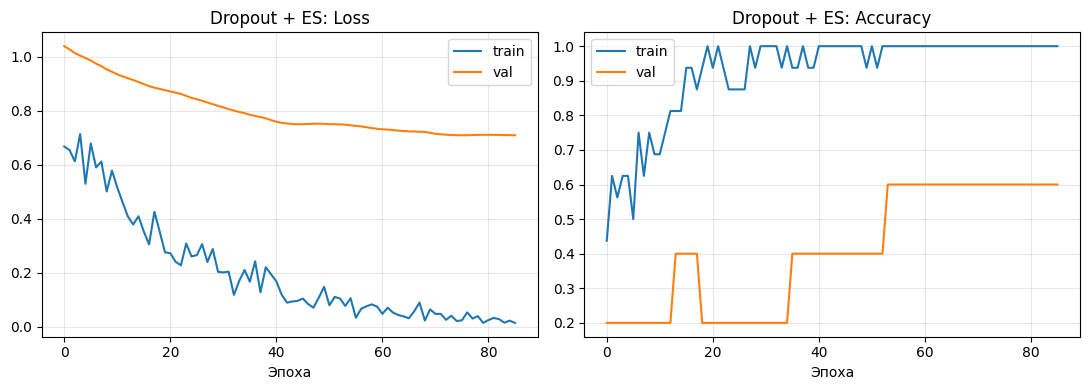

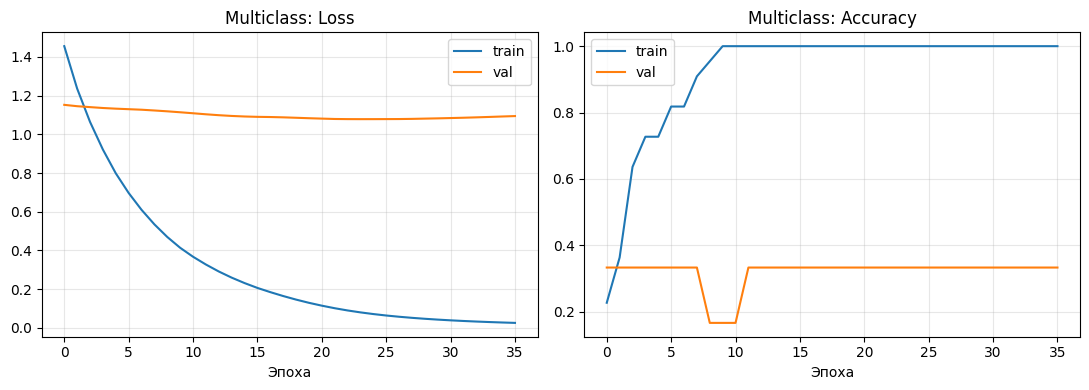

In [23]:
# Графики обучения для улучшенной бинарной и мультиклассовой моделей

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_dropout.history["loss"], label="train")
axes[0].plot(history_dropout.history["val_loss"], label="val")
axes[0].set_title("Dropout + ES: Loss")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_dropout.history["accuracy"], label="train")
axes[1].plot(history_dropout.history["val_accuracy"], label="val")
axes[1].set_title("Dropout + ES: Accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_multi.history["loss"], label="train")
axes[0].plot(history_multi.history["val_loss"], label="val")
axes[0].set_title("Multiclass: Loss")
axes[0].set_xlabel("Эпоха")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_multi.history["accuracy"], label="train")
axes[1].plot(history_multi.history["val_accuracy"], label="val")
axes[1].set_title("Multiclass: Accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Пункт 3: Сравнение 3 архитектур (бинарная задача)

Сравниваем три варианта сети на одинаковом train/test split:
- A_small: один скрытый слой
- B_medium: два скрытых слоя
- C_dropout: более широкая сеть с Dropout

In [20]:
def build_binary_model(name, input_dim):
    if name == "A_small":
        return keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="sigmoid"),
        ])

    if name == "B_medium":
        return keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(32, activation="relu"),
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="sigmoid"),
        ])

    if name == "C_dropout":
        return keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.30),
            layers.Dense(32, activation="relu"),
            layers.Dense(1, activation="sigmoid"),
        ])

    raise ValueError(f"Неизвестная архитектура: {name}")


architectures = ["A_small", "B_medium", "C_dropout"]
rows = []

for arch in architectures:
    keras.utils.set_random_seed(42)

    model_cmp = build_binary_model(arch, X_train.shape[1])
    model_cmp.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    es_cmp = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
    )

    history_cmp = model_cmp.fit(
        X_train, y_train,
        epochs=120,
        batch_size=8,
        validation_split=0.2,
        callbacks=[es_cmp],
        verbose=0,
    )

    y_pred_cmp = (model_cmp.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

    rows.append({
        "architecture": arch,
        "epochs": len(history_cmp.history["loss"]),
        "F1": round(f1_score(y_test, y_pred_cmp, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred_cmp, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred_cmp, zero_division=0), 4),
    })

comparison_df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
comparison_df

,architecture,epochs,F1,Precision,Recall
0,C_dropout,9,0.6667,0.5000,1.00
1,B_medium,23,0.4000,0.3333,0.50
2,A_small,13,0.2222,0.2000,0.25


## Итог по требованиям

Что закрыто в этом ноутбуке:
1. Подготовка данных: TF-IDF + train/test split.
2. Бинарная модель keras (`Dense + ReLU + sigmoid`, `binary_crossentropy`) и обучение через `fit()`.
3. Метрики `F1`, `Precision`, `Recall` и графики `loss/accuracy`.
4. Текстовые пояснения: слои, loss, `fit()`, `predict()`.
5. Дополнительно для уровня 2:
   - Dropout + EarlyStopping
   - Мультикласс (3 класса) через `softmax + categorical_crossentropy`
   - Сравнение 3 архитектур в таблице

Ноутбук можно сдавать как решение до 10 баллов.